<a href="https://colab.research.google.com/github/adyba715/finance-projects/blob/main/project-volatilite/notebooks/volatilite_garch_apple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

In [2]:
history=yf.Ticker("AAPL").history("5y")
history


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-08-02 00:00:00-04:00,142.664674,143.239774,141.582699,141.845886,62880000,0.00,0.0
2021-08-03 00:00:00-04:00,142.128612,144.302305,141.514513,143.639481,64786600,0.00,0.0
2021-08-04 00:00:00-04:00,143.551720,144.058580,142.586710,143.239792,56368300,0.00,0.0
2021-08-05 00:00:00-04:00,143.269049,144.107336,142.479502,143.347031,46397700,0.00,0.0
2021-08-06 00:00:00-04:00,142.868662,143.610578,142.165788,142.663651,54126800,0.22,0.0
...,...,...,...,...,...,...,...
2026-07-27 00:00:00-04:00,334.540009,339.570007,334.019989,336.910004,49604300,0.00,0.0
2026-07-28 00:00:00-04:00,340.029999,342.890015,335.600006,340.079987,51859000,0.00,0.0
2026-07-29 00:00:00-04:00,339.730011,344.570007,337.350006,338.190002,56090800,0.00,0.0


In [3]:
CCAjustés=history["Close"]
CCAjustés


,Close
Date,
2021-08-02 00:00:00-04:00,141.845886
2021-08-03 00:00:00-04:00,143.639481
2021-08-04 00:00:00-04:00,143.239792
2021-08-05 00:00:00-04:00,143.347031
2021-08-06 00:00:00-04:00,142.663651
...,...
2026-07-27 00:00:00-04:00,336.910004
2026-07-28 00:00:00-04:00,340.079987
2026-07-29 00:00:00-04:00,338.190002


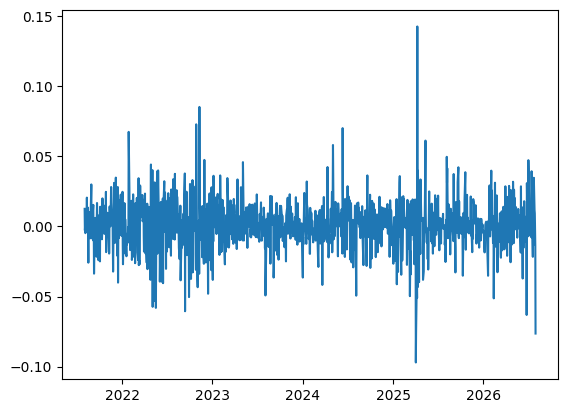

In [4]:
log_r=np.log(CCAjustés/CCAjustés.shift(1)).dropna()
log_r
plt.plot(log_r)



In [6]:
from statsmodels.stats.diagnostic import het_arch

In [7]:
stat, p_value,_,_= het_arch(log_r, nlags=5)
print(f"Statistique de test : {stat:.4f}")
print(f"P-value : {p_value:.4f}")

Statistique de test : 118.6779
P-value : 0.0000


La P-value est quasi-nulle, on rejette H0 càd il y a hétéroscédasticité

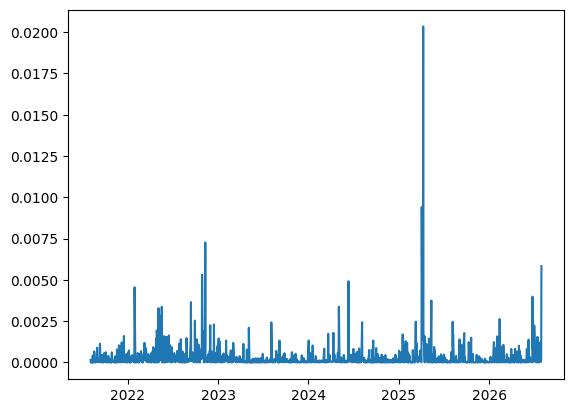

In [8]:
plt.plot(log_r**2)

In [9]:
!pip install arch

from arch import arch_model


log_rpct = log_r* 100


modele = arch_model(log_rpct, vol='Garch', p=1, q=1)


resultat = modele.fit()
print(resultat.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.4 MB/s eta 0:00:00
Iteration:      1,   Func. Count:      6,   Neg. LLF: 5266.531372258189
Iteration:      2,   Func. Count:     16,   Neg. LLF: 119512.40229361384
Iteration:      3,   Func. Count:     24,   Neg. LLF: 2982.123502955321
Iteration:      4,   Func. Count:     32,   Neg. LLF: 2841.7836260398503
Iteration:      5,   Func. Count:     40,   Neg. LLF: 2410.902329210033
Iteration:      6,   Func. Count:     45,   Neg. LLF: 2410.9011651094906
Iteration:      7,   Func. Count:     50,   Neg. LLF: 2410.901116244329
Iteration:      8,   Func. Count:     55,   Neg. LLF: 2410.9010993377656
Iteration:      9,   Func. Count:     59,   Neg. LLF: 2410.9010993396532
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2410.9010993377656
            Iterations: 9
            Function evaluations: 59
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results   

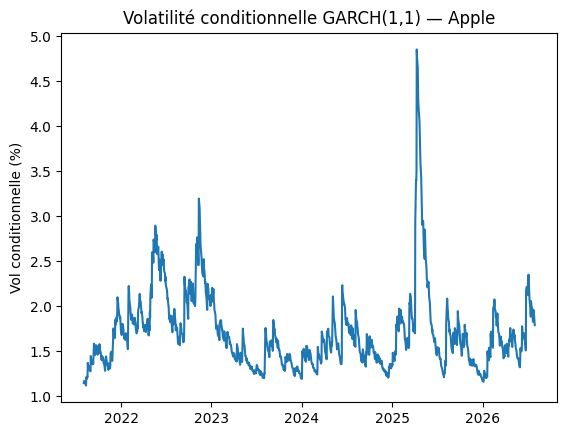

In [10]:
vol_conditionnelle = resultat.conditional_volatility
plt.plot(vol_conditionnelle)
plt.title("Volatilité conditionnelle GARCH(1,1) — Apple")
plt.ylabel("Vol conditionnelle (%)")
plt.show()

In [11]:


# GJR-GARCH
modele_gjr = arch_model(log_rpct, vol='Garch', p=1, o=1, q=1)
resultat_gjr = modele_gjr.fit(disp='off')
print(resultat_gjr.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -2395.68
Distribution:                  Normal   AIC:                           4801.36
Method:            Maximum Likelihood   BIC:                           4827.03
                                        No. Observations:                 1254
Date:                Sat, Aug 01 2026   Df Residuals:                     1253
Time:                        17:35:08   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0679  4.397e-02      1.544      0.123 [-1.83

In [12]:
modele_egarch = arch_model(log_rpct, vol='EGARCH', p=1, o=1, q=1)
resultat_egarch = modele_egarch.fit(disp='off')
print(resultat_egarch.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -2392.60
Distribution:                  Normal   AIC:                           4795.20
Method:            Maximum Likelihood   BIC:                           4820.87
                                        No. Observations:                 1254
Date:                Sat, Aug 01 2026   Df Residuals:                     1253
Time:                        17:35:17   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0509  4.392e-02      1.158      0.247 [-3.52

# **Prévision** **de** **la** **volatilité**




In [13]:
# Prévision à 10 jours
prevision = resultat.forecast(horizon=10)
vol_prevue = np.sqrt(prevision.variance.values[-1])

print(vol_prevue)

[2.58260825 2.56347022 2.54473996 2.52641071 2.50847575 2.49092843
 2.47376219 2.45697048 2.44054685 2.4244849 ]


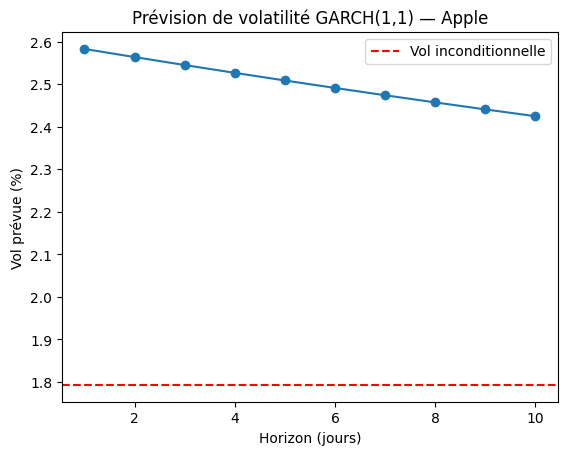

In [14]:
plt.plot(range(1, 11), vol_prevue, marker='o')
plt.axhline(y=np.sqrt(resultat.params['omega']/(1-resultat.params['alpha[1]']-resultat.params['beta[1]'])),
            color='red', linestyle='--', label='Vol inconditionnelle')
plt.xlabel("Horizon (jours)")
plt.ylabel("Vol prévue (%)")
plt.title("Prévision de volatilité GARCH(1,1) — Apple")
plt.legend()
plt.show()

## **Train-Test**

In [15]:

n = len(log_r)
n_train = int(n * 0.8)

rendements_train = log_r.iloc[:n_train]
rendements_test  = log_r.iloc[n_train:]

print(f"Train : {n_train} observations")
print(f"Test  : {len(rendements_test)} observations")

Train : 1003 observations
Test  : 251 observations


In [16]:

import pandas as pd


previsions = []
realisations = []

for t in range(n_train, n-1):
    # Données disponibles jusqu'à t
    donnees_disponibles = log_r.iloc[:t] * 100

    # Estimer GARCH(1,1)
    modele = arch_model(donnees_disponibles, vol='Garch', p=1, q=1)
    res = modele.fit(disp='off')

    # Prévoir σ²_{t+1}
    prev = res.forecast(horizon=1)
    vol_prevue = np.sqrt(prev.variance.values[-1][0])

    # Réalisation réelle — |u_{t+1}|
    realisation = abs(log_r.iloc[t+1] * 100)

    previsions.append(vol_prevue)
    realisations.append(realisation)

previsions = np.array(previsions)
realisations = np.array(realisations)
print("Rolling forecast terminé —", len(previsions), "prévisions")

Rolling forecast terminé — 250 prévisions


In [17]:
# MSE
MSE = np.mean((previsions - realisations)**2)

# QLIKE
QLIKE = np.mean(realisations**2 / previsions**2 + np.log(previsions**2))

print(f"MSE   : {MSE:.4f}")
print(f"QLIKE : {QLIKE:.4f}")

MSE   : 1.5694
QLIKE : 1.9891


In [18]:
# Volatilité historique rolling (fenêtre 20 jours)
vol_historique = log_r.iloc[n_train-20:].rolling(20).std() * 100
vol_historique = vol_historique.iloc[20:20+250].values

# MSE benchmark
MSE_naive = np.mean((vol_historique - realisations)**2)
QLIKE_naive = np.mean(realisations**2 / vol_historique**2 + np.log(vol_historique**2))

print(f"GARCH  — MSE: {MSE:.4f}, QLIKE: {QLIKE:.4f}")
print(f"Naïf   — MSE: {MSE_naive:.4f}, QLIKE: {QLIKE_naive:.4f}")

GARCH  — MSE: 1.5694, QLIKE: 1.9891
Naïf   — MSE: 1.5540, QLIKE: 2.1461


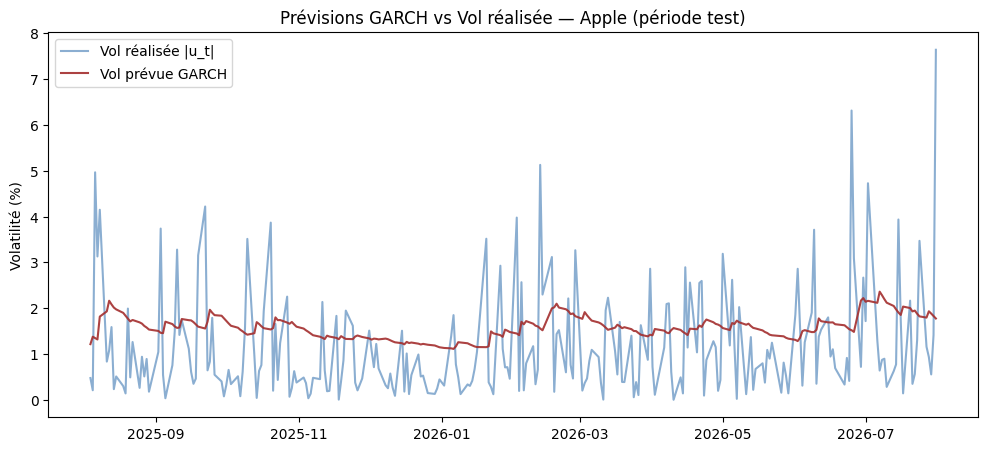

In [19]:
import matplotlib.pyplot as plt

dates_test = log_r.index[n_train+1:n_train+251]

plt.figure(figsize=(12,5))
plt.plot(dates_test, realisations, label='Vol réalisée |u_t|',
         alpha=0.5, color='#185FA5')
plt.plot(dates_test, previsions, label='Vol prévue GARCH',
         alpha=0.9, color='#A32D2D', linewidth=1.5)
plt.title("Prévisions GARCH vs Vol réalisée — Apple (période test)")
plt.ylabel("Volatilité (%)")
plt.legend()
plt.show()

# **Value** **at** **Risk**

**VaR historique**

In [20]:
import scipy.stats as stats

In [21]:
alpha = 0.05
VaR_hist = []

for t in range(n_train, n_train + 250):

    fenetre = log_r.iloc[t-250:t]*100
    percentile=np.percentile(fenetre,alpha*100)
    VaR_hist.append(-percentile)
VaR_hist = np.array(VaR_hist)
print(f"VaR historique moyenne : {VaR_hist.mean():.3f}%")

VaR historique moyenne : 2.833%


**VaR Gaussiene**

In [22]:
mu=np.mean(log_r.iloc[0:n_train])*100

sigma=np.std(log_r.iloc[0:n_train])*100

z=stats.norm.ppf(0.05)
VaR_Gaussienne=-(mu+z*sigma)
print(f"VaR Gaussienne: {VaR_Gaussienne:.2f}%")


VaR Gaussienne: 2.91%


**VaR GARCH**

In [23]:
VaR_GARCH=-(mu+z*previsions)
print(f"Var GARCH: {VaR_GARCH.mean():.2f}%")

Var GARCH: 2.57%


In [24]:
print(type(VaR_Gaussienne))
print(VaR_Gaussienne)

<class 'numpy.float64'>
2.9059948830448303


In [25]:
VaR_gauss = np.full(250, VaR_Gaussienne)
print(VaR_gauss.shape)

(250,)


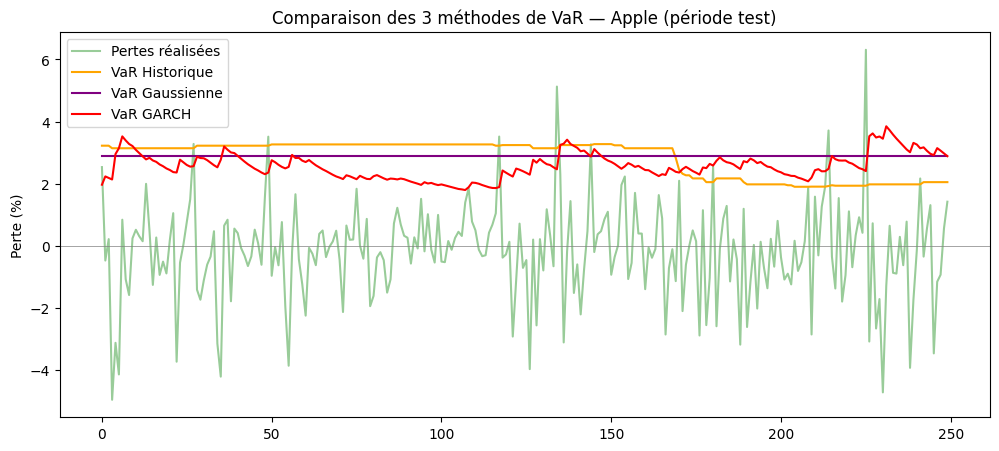

In [26]:
rendements_test = log_r.iloc[n_train:n_train+250] * 100
pertes = -rendements_test.values

plt.figure(figsize=(12,5))
plt.plot(pertes, color='green', alpha=0.4, label='Pertes réalisées')
plt.plot(VaR_hist, color='orange', label='VaR Historique')
plt.plot(VaR_gauss, color='purple', label='VaR Gaussienne')
plt.plot(VaR_GARCH, color='red', label='VaR GARCH')
plt.axhline(0, color='gray', linewidth=0.5)
plt.title("Comparaison des 3 méthodes de VaR — Apple (période test)")
plt.ylabel("Perte (%)")
plt.legend()
plt.show()

In [27]:
pertes = -log_r.iloc[n_train:n_train+250].values * 100

depass_hist  = np.sum(pertes > VaR_hist)
depass_gauss = np.sum(pertes > VaR_gauss)
depass_garch = np.sum(pertes > VaR_GARCH)

print(f"Dépassements attendus (5%)  : {int(0.05*250)}")
print(f"Dépassements VaR Historique : {depass_hist}")
print(f"Dépassements VaR Gaussienne : {depass_gauss}")
print(f"Dépassements VaR GARCH      : {depass_garch}")

Dépassements attendus (5%)  : 12
Dépassements VaR Historique : 10
Dépassements VaR Gaussienne : 7
Dépassements VaR GARCH      : 8


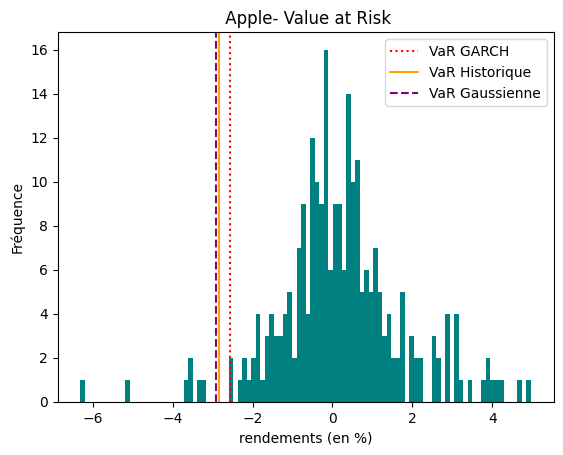

In [28]:

rendements_test = log_r.iloc[n_train:n_train+250] * 100


plt.hist(rendements_test,bins=100 ,color="teal")
plt.axvline(-VaR_GARCH.mean(),color="red", label="VaR GARCH",linestyle=":")
plt.axvline(-VaR_hist.mean(),color="orange", label="VaR Historique",linestyle="-")
plt.axvline(-VaR_gauss.mean(),color="purple", label="VaR Gaussienne",linestyle="--")
plt.legend()
plt.xlabel("rendements (en %)")
plt.ylabel("Fréquence")
plt.title(" Apple- Value at Risk")
plt.show()

# **Expected Shortfall**

**ES historique**

In [29]:
pertes = -log_r.iloc[n_train:n_train+250].values * 100


filtre_hist = pertes > VaR_hist
ES_hist = np.mean(pertes[filtre_hist])
ES_hist


np.float64(3.5350654688462138)

In [30]:

filtre_gauss = pertes > VaR_gauss
ES_gauss = np.mean(pertes[filtre_gauss])
ES_gauss

np.float64(4.103977067694488)

In [31]:

filtre_garch = pertes > VaR_GARCH
ES_garch = np.mean(pertes[filtre_garch])
ES_garch


np.float64(3.9074999621196778)

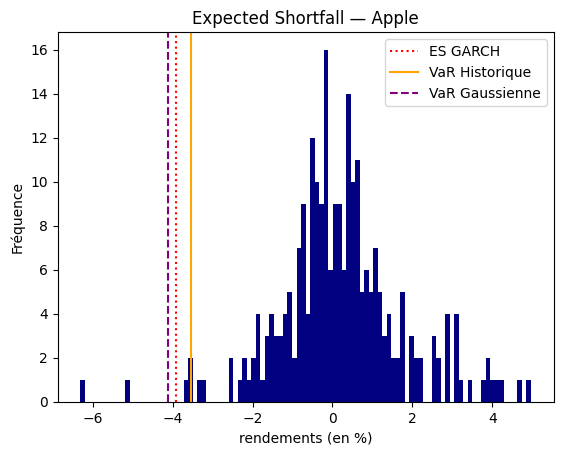

In [32]:
plt.hist(rendements_test,bins=100 ,color="navy")
plt.axvline(-ES_garch,color="red", label="ES GARCH",linestyle=":")
plt.axvline(-ES_hist,color="orange", label="VaR Historique",linestyle="-")
plt.axvline(-ES_gauss,color="purple", label="VaR Gaussienne",linestyle="--")
plt.legend()
plt.xlabel("rendements (en %)")
plt.ylabel("Fréquence")
plt.title("Expected Shortfall — Apple")
plt.show()

# **BackTest**

**Test de Kupiec**

In [33]:
def test_kupiec(x, T, alpha=0.05):
    p_obs = x / T
    LR = -2*(x*np.log(alpha/p_obs)+(T-x)*np.log((1-alpha)/(1-p_obs)))
    p_value = 1 - stats.chi2.cdf(LR, df=1)
    return LR, p_value

In [34]:
T = 250

for nom, x in [("Historique", depass_hist),
                ("Gaussienne", depass_gauss),
                ("GARCH", depass_garch)]:
    LR, pval = test_kupiec(x, T)
    print(f"VaR {nom:12} : {x} dépass. | LR={LR:.3f} | p-value={pval:.3f}")

VaR Historique   : 10 dépass. | LR=0.563 | p-value=0.453
VaR Gaussienne   : 7 dépass. | LR=3.009 | p-value=0.083
VaR GARCH        : 8 dépass. | LR=1.944 | p-value=0.163


# **Comparaison des modèles**

In [35]:
res_garch  = arch_model(log_rpct, vol='Garch',  p=1, q=1).fit(disp='off')
res_gjr    = arch_model(log_rpct, vol='Garch',  p=1, o=1, q=1).fit(disp='off')
res_egarch = arch_model(log_rpct, vol='EGARCH', p=1, o=1, q=1).fit(disp='off')

print(f"GARCH(1,1)  — AIC: {res_garch.aic:.2f}, BIC: {res_garch.bic:.2f}")
print(f"GJR-GARCH   — AIC: {res_gjr.aic:.2f}, BIC: {res_gjr.bic:.2f}")
print(f"EGARCH      — AIC: {res_egarch.aic:.2f}, BIC: {res_egarch.bic:.2f}")

GARCH(1,1)  — AIC: 4829.80, BIC: 4850.34
GJR-GARCH   — AIC: 4801.36, BIC: 4827.03
EGARCH      — AIC: 4795.20, BIC: 4820.87


# **Variance Risk Premium**

In [36]:
# Importer les modules du Projet 1
!wget -q https://raw.githubusercontent.com/adyba715/finance-projects/main/project-1-bs-pricer/bs_pricer.py
!wget -q https://raw.githubusercontent.com/adyba715/finance-projects/main/project-1-bs-pricer/vol_impl.py

import sys
for mod in ['bs_pricer', 'vol_impl']:
    if mod in sys.modules:
        del sys.modules[mod]

from bs_pricer import Option
from vol_impl import vol_implicite

In [37]:
import yfinance as yf
import datetime as dt
import numpy as np

# Prix actuel Apple
ticker = yf.Ticker("AAPL")
S = ticker.history(period="1d")['Close'].iloc[-1]

# Trouver une maturité d'environ 30 jours
for date_mat in ticker.options:
    date_mat_obj = dt.datetime.strptime(date_mat, '%Y-%m-%d')
    T = (date_mat_obj - dt.datetime.now()).days / 365
    if T >= 20/365:
        maturite = date_mat
        break

print(f"S = {S:.2f}$")
print(f"Maturité : {maturite}, T = {T*365:.0f} jours")

# Récupérer le call ATM (strike le plus proche de S)
calls = ticker.option_chain(maturite).calls
calls['diff'] = abs(calls['strike'] - S)
call_atm = calls.loc[calls['diff'].idxmin()]

print(f"Strike ATM : {call_atm['strike']}")
print(f"Prix ATM   : {call_atm['lastPrice']}")

S = 308.91$
Maturité : 2026-08-28, T = 26 jours
Strike ATM : 310.0
Prix ATM   : 8.9


In [38]:
r = 0.04  # taux sans risque actuel

vol_imp_atm = vol_implicite(8.9, S, 310.0, r, T, "call")
print(f"Vol implicite ATM Apple aujourd'hui : {vol_imp_atm*100:.2f}%")

Vol implicite ATM Apple aujourd'hui : 27.37%


In [39]:
# Dernière vol conditionnelle GARCH (annualisée)
derniere_vol_garch = res_egarch.conditional_volatility.iloc[-1] / 100 * np.sqrt(252)

print(f"Vol implicite ATM (marché)  : {vol_imp_atm*100:.2f}%")
print(f"Vol GARCH (historique)      : {derniere_vol_garch*100:.2f}%")
print(f"VRP empirique               : {(vol_imp_atm - derniere_vol_garch)*100:.2f}%")

Vol implicite ATM (marché)  : 27.37%
Vol GARCH (historique)      : 26.24%
VRP empirique               : 1.13%
